## Underfit Overfit Goodfit

1. Underfitting — mô hình học chưa đủ
Mô hình quá đơn giản, chưa học được quy luật của dữ liệu.

2. Overfitting — mô hình học quá kỹ dữ liệu train
Model không chỉ học quy luật, mà còn "học thuộc" cả nhiễu và những chi tiết riêng của tập train.

3. Mục tiêu - Good fit
Tốt

- Underfit = chưa học được bài.
- Good fit = hiểu bài.
- Overfit = học thuộc lòng.  

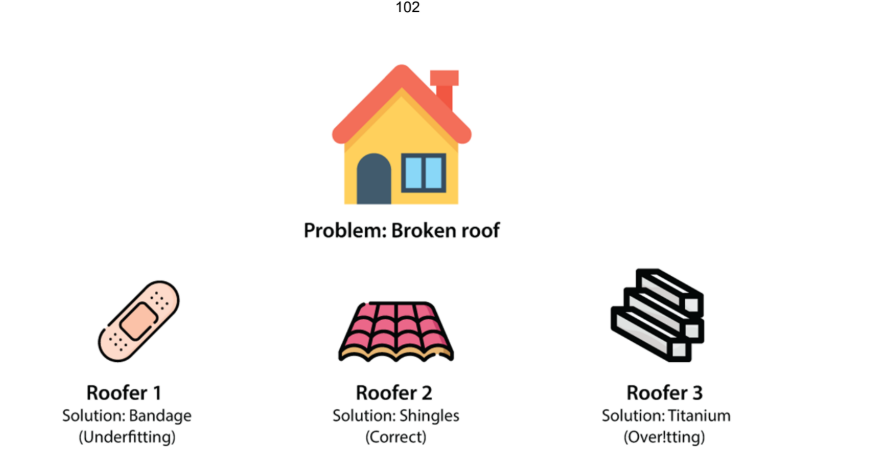


## GOLDEN RULE Thou shalt never use your testing data for training.

## Train, test, Validation

- Validation set là tập dữ liệu dùng để chọn và điều chỉnh model trong quá trình phát triển, nhưng không dùng để train model.
- Train là để học
- Test là kiểm tra

- Ví dụ bài chọn bậc của đa thức khi ta chưa biết nó là bậc mấy
<pre>
Train:
degree=1  → train model A
degree=2  → train model B
degree=5  → train model C
degree=10 → train model D

              ↓

Validation:
degree=1  → error = 10
degree=2  → error = 5   ← tốt nhất
degree=5  → error = 7
degree=10 → error = 20

              ↓
        chọn degree=2

              ↓

Test:
đánh giá degree=2 lần cuối
</pre>


### Model Complexity Graph 
- là đồ thị giúp ta xem model đơn giản hay phức tạp đến mức nào, từ đó phát hiện underfitting / overfitting và chọn mức độ phức tạp phù hợp.  


### Measuring how complex a model is: L1 and L2 norm  
Regularization term = một đại lượng dùng để đo độ phức tạp của model. Nó có thể là L1 norm hoặc L2 norm của các weight.

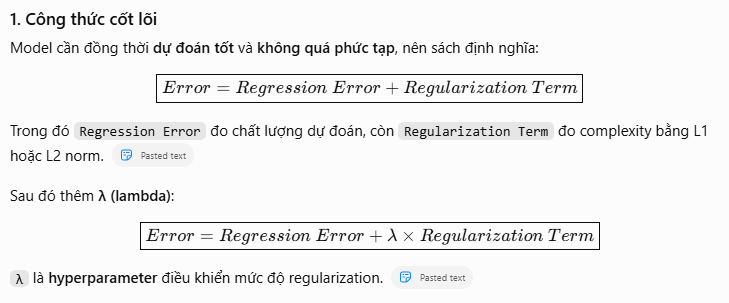
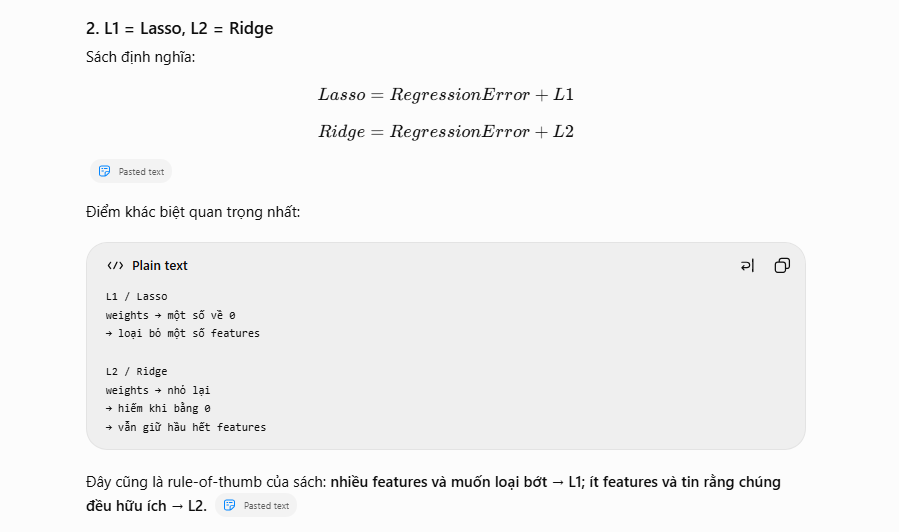

### Regularization (Điều chuẩn hóa)

Mục tiêu là tìm sự cân bằng: mô hình vừa dự đoán chính xác, vừa giữ cấu trúc đơn giản để tránh Overfitting.

$$Error = \text{Regression Error} + \lambda \times \text{Regularization Term}$$

- **Regression Error:** Đo lường sai số dự đoán (chất lượng khớp dữ liệu).
- **Regularization Term:** Đo lường độ phức tạp qua chuẩn $L_1$ ($\sum |w|$) hoặc $L_2$ ($\sum w^2$).
- **$\lambda$ (Lambda):** Siêu tham số (hyperparameter) cân bằng giữa sai số và độ phức tạp:
  - $\lambda \to 0$: Mô hình tự do phức tạp (nguy cơ Overfitting).
  - $\lambda \to \infty$: Mô hình bị phạt nặng, quá đơn giản (nguy cơ Underfitting).


| Đặc điểm | L1 Regularization (Lasso) | L2 Regularization (Ridge) |
| :--- | :--- | :--- |
| **Công thức phạt** | $\sum \vert w_i \vert$ | $\sum w_i^2$ |
| **Cách ép trọng số** | Ép thẳng các trọng số không quan trọng về chính xác bằng 0. | Thu nhỏ các trọng số về rất gần 0, nhưng hiếm khi bằng 0. |
| **Tác dụng chính** | Feature selection (chọn lọc đặc trưng, làm mô hình thưa - sparse). | Giảm độ nhạy của mô hình với nhiễu và xử lý hiện tượng đa cộng tuyến. |


có thể hiểu là cái L1 giống MAE là lấy abs còn L2 là giốgn MSE là bình mà cái kia là y- y mủ còn bên này là tính theo weight w


In [ ]:
from sklearn.linear_model import Ridge, Lasso

model = Ridge(alpha=1.0)   # L2
# model = Lasso(alpha=0.01)  # L1

model.fit(X_train, y_train)       # Học weights
y_pred = model.predict(X_val)    # Đánh giá trên validation

alpha nhỏ → phạt weights yếu.  
alpha lớn → phạt mạnh, quá lớn có thể underfit.  
Thử nhiều alpha, chọn bằng validation hoặc cross-validation.  
Weights được học qua fit(), còn alpha do bạn đặt hoặc tìm bằng grid search.